In [1]:
import numpy as np
import json
import pandas as pd
import pyarrow.parquet as pq
from tqdm.auto import tqdm
import os
import xgboost as xgb
import matplotlib.pyplot as plt
from pathlib import Path
import pickle
import hist
import importlib
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# le = OrdinalEncoder

import mplhep as hep
plt.style.use([hep.style.CMS])
from common_bb_cc import common_mc
import batch_iterator
importlib.reload(batch_iterator)
from batch_iterator import Iterator
from sklearn.model_selection import train_test_split


/uscms_data/d3/bweiss/micromamba/envs/hbb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42, shuffle=True, #stratify = X['isSignal']
                                  )

In [2]:
import batch_iterator
importlib.reload(batch_iterator)
from batch_iterator import Iterator

params = {
    # 'n_estimators':100,  # number of boosting rounds (i.e. number of decision trees)
    'max_depth':8,  # max depth of each decision tree
    'learning_rate':0.5,
    # 'early_stopping_rounds':20,  #Remove this # how many rounds to wait to see if the loss is going down
    # 'missing': np.nan,
    # 'scale_pos_weight': pos_weight,
    'eval_metric':'merror',
    'objective': 'multi:softmax',
    'num_class': 3, 
    'verbosity':1,
    # "tree_method": "hist"
}

eval_result={}
data_dir = "/uscms/home/bweiss/nobackup/hbb-run3/data/3cat_BDT_data_22_TEST_2/"
file_paths = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(".parquet")]
metadata_dir = os.path.join(data_dir, "metadata.pkl")
# train_files = file_paths[:-8]
# val_files = file_paths[-8:]

#small sample
train_files = file_paths[:8]
val_files = file_paths[8:10]
print(len(val_files))
print(len(train_files))

cache_files = [file for file in os.listdir('./') if "cache-" in file]
if len(cache_files)>0:
    print('removing cache files: ', cache_files)
    for cache in cache_files:
        os.remove('./'+cache)
        
it_train = Iterator(device="cpu", file_paths=train_files, metadata_path = metadata_dir)
it_val = Iterator(device="cpu", file_paths=val_files, metadata_path = metadata_dir)

Xy_train = xgb.ExtMemQuantileDMatrix(it_train)
Xy_val = xgb.ExtMemQuantileDMatrix(it_val, ref=Xy_train
                                  )


FileNotFoundError: [Errno 2] No such file or directory: '/uscms/home/bweiss/nobackup/hbb-run3/data/3cat_BDT_data_22_TEST_2/'

In [4]:
model = xgb.train(params, 
         Xy_train, 
         10, #100
         # evals = [(DM_train, 'train'), (DM_test, 'test')],
         # evals=[(Xy_train, "Train"), (Xy_val, "Val")],
         # evals_result = evals_result,
         # verbosity = 1
         )

XGBoostError: [01:09:33] /workspace/src/objective/multiclass_obj.cu:68: Check failed: valid: SoftmaxMultiClassObj: label must be discrete values in the range of [0, num_class).
Stack trace:
  [bt] (0) /uscms_data/d3/bweiss/micromamba/envs/hbb/lib/python3.10/site-packages/xgboost/lib/libxgboost.so(+0x2bdf8c) [0x7f4a114cff8c]
  [bt] (1) /uscms_data/d3/bweiss/micromamba/envs/hbb/lib/python3.10/site-packages/xgboost/lib/libxgboost.so(+0xfe9a74) [0x7f4a121fba74]
  [bt] (2) /uscms_data/d3/bweiss/micromamba/envs/hbb/lib/python3.10/site-packages/xgboost/lib/libxgboost.so(+0xff3895) [0x7f4a12205895]
  [bt] (3) /uscms_data/d3/bweiss/micromamba/envs/hbb/lib/python3.10/site-packages/xgboost/lib/libxgboost.so(+0x6f5045) [0x7f4a11907045]
  [bt] (4) /uscms_data/d3/bweiss/micromamba/envs/hbb/lib/python3.10/site-packages/xgboost/lib/libxgboost.so(XGBoosterUpdateOneIter+0x77) [0x7f4a113dca67]
  [bt] (5) /uscms_data/d3/bweiss/micromamba/envs/hbb/lib/python3.10/lib-dynload/../../libffi.so.8(+0x702a) [0x7f

In [7]:
# features = model.feature_names
importance = model.get_score()
# print(importance, type(importance))
imps = [imp for k , imp in importance.items()]
fi = pd.DataFrame({'features': importance.keys(), 'importance': imps})
fi = fi.sort_values(by = 'importance', ascending=False).reset_index(drop=True)
print(fi)

                  features  importance
0             VBFPair_deta       257.0
1         Jet1_btagPNetQvG       251.0
2                     nJet       223.0
3              VBFPair_mjj       209.0
4      FatJet1_ParTmassX2p       208.0
5         Jet0_btagPNetQvG       182.0
6              FatJet0_eta       179.0
7         FatJet1_ParTPXcs       161.0
8    JetClosestFatJet0_eta       156.0
9         FatJet1_ParTPXqq       142.0
10                 Jet0_pt       134.0
11        FatJet1_ParTPQCD       123.0
12                 Jet1_pt       117.0
13             FatJet1_msd       116.0
14               Jet0_mass       115.0
15            FatJet0_n3b1       102.0
16                Jet0_eta        99.0
17                Jet1_eta        94.0
18    JetClosestFatJet0_pt        91.0
19             FatJet1_eta        89.0
20              FatJet1_pt        84.0
21     FatJet1_ParTPTopbWq        83.0
22        Jet1_btagPNetCvB        83.0
23    FatJet1_ParTPTopbWqq        76.0
24        Jet2_btagPNetQv

In [8]:
model.save_model('BatchedBDT_3Cat_TEST.json')

In [9]:
booster = xgb.XGBClassifier()
booster.load_model('./BatchedBDT_3Cat_TEST.json')
# dir(booster)

0 vbf
N vbf:  10658
1 vh
N vh:  147
2 ggf
N ggf:  3479
----------------------------------------
Predicted vbf purity: 0.7548554828000904)
contains 10658.0 VBF, 147.0 VH, 3479.0 ggF
with yields: 0.7548554828000904 VBF, 0.009213742256792418 VH, 0.2359307749431171 ggF
0 vbf
N vbf:  266
1 vh
N vh:  5673
2 ggf
N ggf:  1421
----------------------------------------
Predicted vh purity: 0.7603711270501803)
contains 266.0 VBF, 5673.0 VH, 1421.0 ggF
with yields: 0.04034123701867477 VBF, 0.7603711270501803 VH, 0.19928763593114499 ggF
0 vbf
N vbf:  11434
1 vh
N vh:  7270
2 ggf
N ggf:  93825
----------------------------------------
Predicted ggf purity: 0.8290045821148863)
contains 11434.0 VBF, 7270.0 VH, 93825.0 ggF
with yields: 0.10060597856075496 VBF, 0.07038943932435875 VH, 0.8290045821148863 ggF


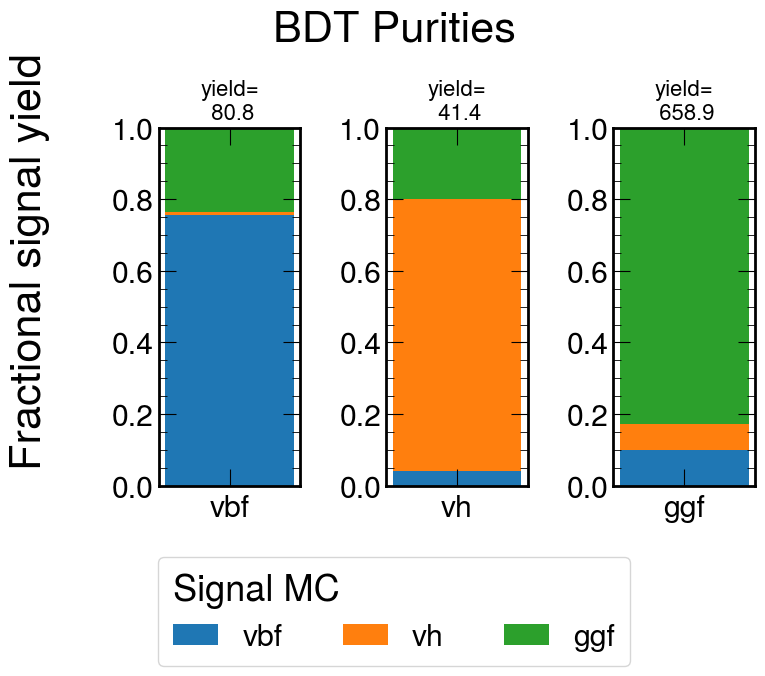

In [11]:
''' Purity plot'''
import mplhep as hep
import matplotlib.colors as mcolors
colors = list(mcolors.TABLEAU_COLORS.keys())

plt.style.use([hep.style.CMS])

# colors = ['blue', 'red', 'green', 'purple', 'orange']
cat2label = {"vbf": 0,
             "vh": 1 ,
             "ggf": 2 ,
            }
label2cat = {0: "vbf",
             1: "vh" ,
             2: "ggf",
            }

omit_cols = ['category','y', 'weight', 'finalWeight', 'sum_genWeight', 'weight_nonorm', 'BDT_weight', 'BDT_cat_weight', 'BDT_era_weight'
            ]

def purity_plot(ax, x_test, category = '', use_weights = False, label =''): # produce a stacked histogram bar with the makeup of that category
    # cat_mask = X_test['category'] == category
    Y_predict = booster.predict_proba(x_test.drop(omit_cols, axis=1))
    # Y_predict = booster.predict(x_test.drop(omit_cols, axis=1))
    # print(Y_predict[:40])
    
    Y_predict = np.argmax(Y_predict, axis = 1)
    cat_index = cat2label[category]
    pred_mask = Y_predict == cat_index
    X_pred = x_test[pred_mask]
    # print(X_pred)
    use_weights = int(use_weights)
    yields = np.zeros((4,2))
    bottom = 0
    for cat in range(3):
        truecat = label2cat[cat]
        print(cat, truecat)
        cat_mask = X_pred['category'] == truecat
        print(f'N {truecat}: ', np.sum(cat_mask))
        yields[cat][:] = [np.sum(cat_mask), 
                          np.sum(X_pred['finalWeight'][cat_mask].values, axis = 0)]
    sumw = np.sum(yields[:,1])
    yields[:,1] = yields[:,1]/ np.sum(yields[:,1])
    # print(yields)
    
    if category == 'ttbar':
        ax.set_yscale('log')
        ax.set_ylim([0.0005,1])
        order=[4,0,1,2,3]
    else:
        ax.set_ylim([0,1])
        order = [0,1,2,]
            
    
    for c in order:
        if c ==3:
            color = colors[4]
        else:
            color = colors[c]
        ax.bar(category, yields[c, use_weights], bottom=bottom, color = color)
        bottom += yields[c,use_weights]
    
        ax.set_title(f'yield=\n {round(sumw, 1)}', fontsize=16)
    print("----------------------------------------")
    print(f'Predicted {category} purity: {yields[cat_index,1]})')
    print(f'contains {yields[0][0]} VBF, {yields[1][0]} VH, {yields[2][0]} ggF')
    print(f'with yields: {yields[0][1]} VBF, {yields[1][1]} VH, {yields[2][1]} ggF')

# def cutBased_purity(ax, df, category = '', use_weights = False, label =''):
#     cut_mask = CutBased_events['true_cat']

    # return sumw
    # bins = [0,1]
    # _, _, patches = 
    # print(le.transform([category]))
    # print()
# print(len(X))
test_file = pd.read_parquet(val_files[-1])
test_data = test_file.drop(['category','y', 'weight', 'finalWeight', 'sum_genWeight', 'weight_nonorm',], axis=1)
DM_test = xgb.DMatrix(test_data, label=test_file['y'], missing = np.nan)


fig, axes  = plt.subplots(1,3, figsize = (8,6))
categories = ['vbf', 'vh', 'ggf', #'tth'#'False'
             ]
for i in range(3):
    a = purity_plot(axes[i], test_file, use_weights = True, category = categories[i])
fig.legend(#[f'{name} \n ({round(true_yields[name], 1)})' for name in categories],
           categories,
           ncol = 3, title= 'Signal MC', alignment='left', loc = 'lower center', frameon=True, bbox_to_anchor=(0.5, -0.2))
fig.suptitle('BDT Purities', x=0.5, y=0.92)
fig.supylabel('Fractional signal yield')
fig.tight_layout()
# plt.savefig('PurityPlot_3cat_WithAK4PNet_26Jul9.png', bbox_inches="tight")